<a href="https://colab.research.google.com/github/kopja3/vihrea_datakeskus/blob/main/datakeskus_co2e_laskuri_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Datakeskuksen hiilidioksidipäästöjen laskuri ja visualisointi

Tämä Google Colab -notebook toteuttaa julkaisukelpoisen, menetelmää havainnollistavan laskurin datakeskuksen hiilidioksidipäästöjen arviointiin ja optimointiskenaarioiden vertaamiseen.

Notebook perustuu menetelmään, jossa päästöt lasketaan aikajaksoittain kaavalla:

**CO₂e(t) = E(t) × EF(t)**

missä:
- **E(t)** = energiankulutus aikavälillä *t* [kWh]
- **EF(t)** = sähkön päästökerroin samalla aikavälillä [gCO₂e/kWh]

Koko tarkastelujakson päästöt saadaan summaamalla aikajaksojen päästöt.

## Mitä notebook tekee?
- lukee mittausdatan CSV-muodossa
- laskee kokonaispäästöt ja osapäästöt
- visualisoi energiankulutuksen, päästökertoimen ja CO₂e-päästöt ajan suhteen
- simuloi kahta optimointia:
  1. **jäähdytyksen optimointi**
  2. **joustavan kuorman siirto** vähäpäästöisemmille tunneille
- vertaa lähtötilannetta ja optimointiskenaariota taulukolla ja kuvilla


## 1. Kirjastot
Aja tämä solu ensin.


In [20]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 50)


## 2. Datan lataus
Voit käyttää joko esimerkkidataa tai ladata oman CSV-tiedoston.

CSV:n vähimmäissarakkeet:
- `timestamp`
- `energy_kwh`
- `emission_factor_gco2e_per_kwh`

Suositellut lisäsarakkeet:
- `it_kwh`
- `cooling_kwh`
- `other_kwh`
- `cpu_utilization_pct`
- `shiftable_workload_pct`


In [21]:
# Valitse datalähde
USE_SAMPLE_DATA = True
SAMPLE_FILE = '/content/datakeskus_paastot_esimerkkidata.csv'

# Jos käytät Colabissa tätä notebookia, voit ladata sample-tiedoston vasemman reunan Files-paneeliin
# tai vaihtaa USE_SAMPLE_DATA = False ja käyttää tiedoston latausta alemmassa solussa.


In [22]:
# Tämä solu lataa tiedoston käsin, jos et käytä sample-dataa.
# Colabissa: suorita tämä vain tarvittaessa.

uploaded_df = None
if not USE_SAMPLE_DATA:
    try:
        from google.colab import files
        uploaded = files.upload()
        if uploaded:
            first_name = next(iter(uploaded))
            uploaded_df = pd.read_csv(io.BytesIO(uploaded[first_name]))
            print(f'Ladattu tiedosto: {first_name}')
    except Exception as e:
        print('Tiedoston lataus ei onnistunut tässä ympäristössä:', e)


In [23]:
if USE_SAMPLE_DATA:
    df = pd.read_csv(SAMPLE_FILE)
else:
    if uploaded_df is None:
        raise ValueError('Tiedostoa ei ladattu. Aseta USE_SAMPLE_DATA=True tai lataa CSV.')
    df = uploaded_df.copy()

# Perussiivous
if 'timestamp' not in df.columns:
    raise ValueError('CSV:stä puuttuu sarake timestamp')
if 'energy_kwh' not in df.columns:
    raise ValueError('CSV:stä puuttuu sarake energy_kwh')
if 'emission_factor_gco2e_per_kwh' not in df.columns:
    raise ValueError('CSV:stä puuttuu sarake emission_factor_gco2e_per_kwh')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

for col in ['it_kwh', 'cooling_kwh', 'other_kwh', 'cpu_utilization_pct', 'shiftable_workload_pct']:
    if col not in df.columns:
        df[col] = np.nan

df.head()


,timestamp,energy_kwh,it_kwh,cooling_kwh,other_kwh,emission_factor_gco2e_per_kwh,cpu_utilization_pct,shiftable_workload_pct
0,2026-01-15 00:00:00,34.00,23.12,8.16,2.72,87.5,35.0,5
1,2026-01-15 01:00:00,34.27,23.31,8.23,2.74,100.8,35.0,5
2,2026-01-15 02:00:00,35.07,23.85,8.42,2.81,115.0,35.0,5
3,2026-01-15 03:00:00,36.34,24.71,8.72,2.91,129.2,35.0,5
4,2026-01-15 04:00:00,38.00,25.84,9.12,3.04,142.5,35.0,5


## 3. Laskentafunktiot


In [24]:
def calculate_baseline(df_in):
    df = df_in.copy()
    df['co2e_g'] = df['energy_kwh'] * df['emission_factor_gco2e_per_kwh']
    df['co2e_kg'] = df['co2e_g'] / 1000

    if df['it_kwh'].notna().any():
        df['it_co2e_kg'] = (df['it_kwh'].fillna(0) * df['emission_factor_gco2e_per_kwh']) / 1000
    else:
        df['it_co2e_kg'] = np.nan

    if df['cooling_kwh'].notna().any():
        df['cooling_co2e_kg'] = (df['cooling_kwh'].fillna(0) * df['emission_factor_gco2e_per_kwh']) / 1000
    else:
        df['cooling_co2e_kg'] = np.nan

    return df


def optimize_cooling(df_in, cooling_reduction_pct=10.0):
    df = df_in.copy()
    if 'cooling_kwh' not in df.columns or df['cooling_kwh'].isna().all():
        raise ValueError('Jäähdytysoptimointi vaatii sarakkeen cooling_kwh.')

    reduction_factor = 1 - cooling_reduction_pct / 100.0
    df['cooling_kwh_optimized'] = df['cooling_kwh'] * reduction_factor
    df['energy_kwh_optimized'] = (
        df['energy_kwh'] - df['cooling_kwh'].fillna(0) + df['cooling_kwh_optimized'].fillna(0)
    )
    df['co2e_kg_optimized'] = (
        df['energy_kwh_optimized'] * df['emission_factor_gco2e_per_kwh']
    ) / 1000
    return df


def shift_workloads_to_cleaner_hours(df_in, shift_share_pct=20.0):
    """
    Yksinkertainen havainnollistava malli:
    - Jokaiselta tunnilta siirretään shift_share_pct osuus IT-energiasta pois.
    - Siirretty energia jaetaan pienimmän päästökertoimen tunneille suhteessa niiden "vastaanottokapasiteettiin".
    Tämä ei ole tuotantotason optimointialgoritmi vaan julkaisussa havainnollistava skenaario.
    """
    df = df_in.copy()
    if 'it_kwh' not in df.columns or df['it_kwh'].isna().all():
        raise ValueError('Kuormansiirto vaatii sarakkeen it_kwh.')

    base_it = df['it_kwh'].fillna(0).values.astype(float)
    ef = df['emission_factor_gco2e_per_kwh'].values.astype(float)

    movable = base_it * (shift_share_pct / 100.0)
    remaining_it = base_it - movable
    total_movable = movable.sum()

    # Vastaanottokapasiteetti suosii vähäpäästöisiä tunteja
    inv = 1 / np.maximum(ef, 1e-6)
    weights = inv / inv.sum()
    added = total_movable * weights

    shifted_it = remaining_it + added

    df['it_kwh_shifted'] = shifted_it
    if 'cooling_kwh' in df.columns and df['cooling_kwh'].notna().any() and 'other_kwh' in df.columns:
        df['energy_kwh_shifted'] = df['it_kwh_shifted'] + df['cooling_kwh'].fillna(0) + df['other_kwh'].fillna(0)
    else:
        # fallback: oletetaan kokonaiskulutus muuttuu IT-energian mukana
        df['energy_kwh_shifted'] = df['energy_kwh'] - base_it + df['it_kwh_shifted']

    df['co2e_kg_shifted'] = (
        df['energy_kwh_shifted'] * df['emission_factor_gco2e_per_kwh']
    ) / 1000
    return df


def summarize_results(base_df, cool_df=None, shift_df=None):
    rows = []
    rows.append({
        'Skenaario': 'Lähtötilanne',
        'Energia yhteensä (kWh)': round(base_df['energy_kwh'].sum(), 2),
        'CO2e yhteensä (kg)': round(base_df['co2e_kg'].sum(), 2),
        'Keskimääräinen päästöintensiteetti (g/kWh)': round(base_df['emission_factor_gco2e_per_kwh'].mean(), 2)
    })
    if cool_df is not None:
        rows.append({
            'Skenaario': 'Jäähdytys optimoitu',
            'Energia yhteensä (kWh)': round(cool_df['energy_kwh_optimized'].sum(), 2),
            'CO2e yhteensä (kg)': round(cool_df['co2e_kg_optimized'].sum(), 2),
            'Keskimääräinen päästöintensiteetti (g/kWh)': round(cool_df['emission_factor_gco2e_per_kwh'].mean(), 2)
        })
    if shift_df is not None:
        rows.append({
            'Skenaario': 'Kuormaa siirretty',
            'Energia yhteensä (kWh)': round(shift_df['energy_kwh_shifted'].sum(), 2),
            'CO2e yhteensä (kg)': round(shift_df['co2e_kg_shifted'].sum(), 2),
            'Keskimääräinen päästöintensiteetti (g/kWh)': round(shift_df['emission_factor_gco2e_per_kwh'].mean(), 2)
        })
    return pd.DataFrame(rows)


## 4. Asetukset
Voit muuttaa näitä arvoja ja ajaa solut uudelleen.


In [25]:
COOLING_REDUCTION_PCT = 12   # esim. 12 % vähemmän jäähdytysenergiaa
SHIFTABLE_IT_SHARE_PCT = 25  # esim. 25 % IT-kuormasta siirretään puhtaammille tunneille


## 5. Laskenta


In [26]:
base = calculate_baseline(df)

cool = None
try:
    cool = optimize_cooling(df, cooling_reduction_pct=COOLING_REDUCTION_PCT)
except Exception as e:
    print('Jäähdytysskenaariota ei voitu laskea:', e)

shift = None
try:
    shift = shift_workloads_to_cleaner_hours(df, shift_share_pct=SHIFTABLE_IT_SHARE_PCT)
except Exception as e:
    print('Kuormansiirtoskenaariota ei voitu laskea:', e)

summary = summarize_results(base, cool, shift)
summary


,Skenaario,Energia yhteensä (kWh),CO2e yhteensä (kg),Keskimääräinen päästöintensiteetti (g/kWh)
0,Lähtötilanne,1044.00,125.94,117.5
1,Jäähdytys optimoitu,1013.93,122.31,117.5
2,Kuormaa siirretty,1044.00,122.60,117.5


## 6. Visualisointi


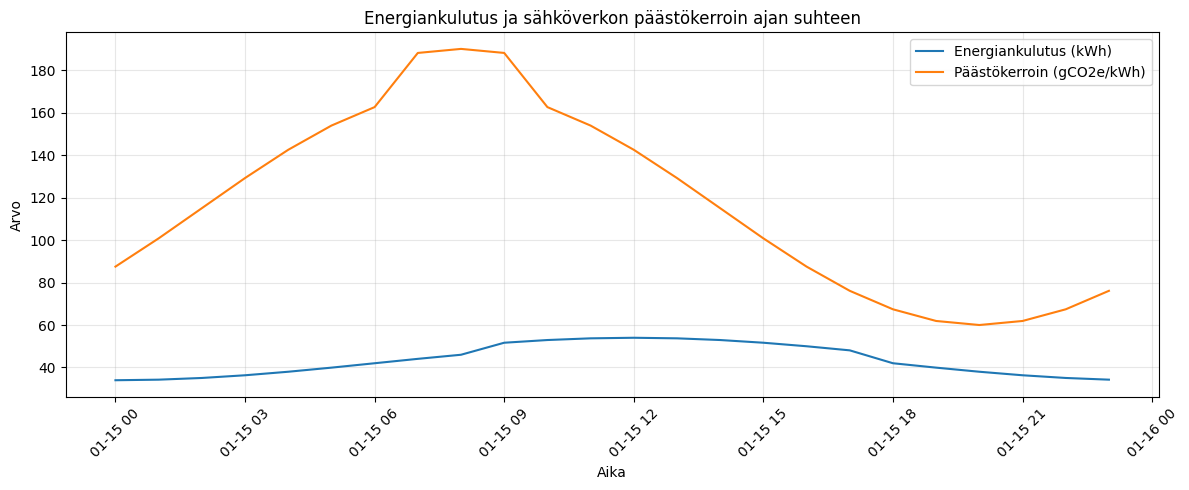

In [27]:
# Kuva 1: Energiankulutus ja päästökerroin
plt.figure()
plt.plot(base['timestamp'], base['energy_kwh'], label='Energiankulutus (kWh)')
plt.plot(base['timestamp'], base['emission_factor_gco2e_per_kwh'], label='Päästökerroin (gCO2e/kWh)')
plt.title('Energiankulutus ja sähköverkon päästökerroin ajan suhteen')
plt.xlabel('Aika')
plt.ylabel('Arvo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


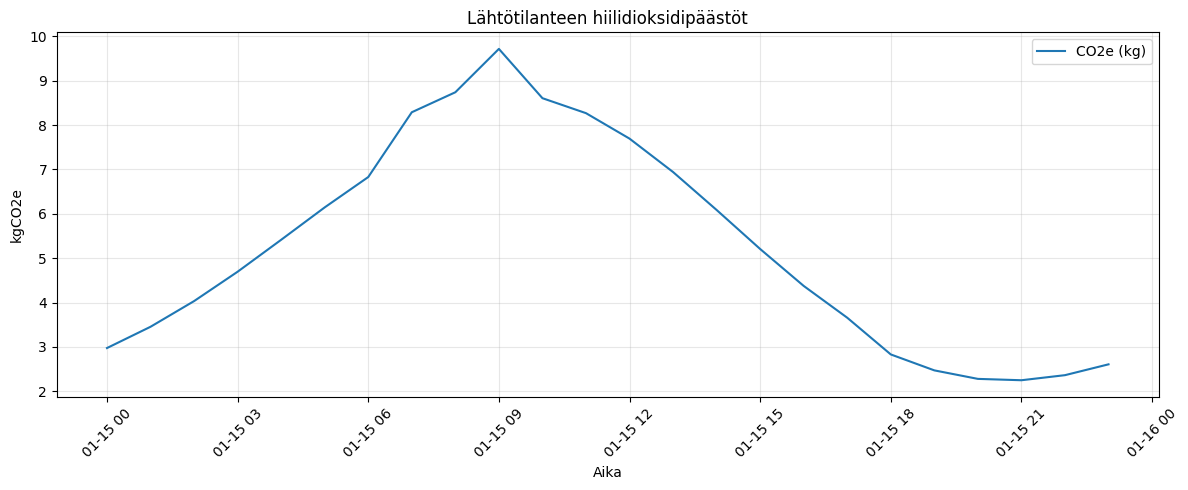

In [28]:
# Kuva 2: Lähtötilanteen CO2e-päästöt
plt.figure()
plt.plot(base['timestamp'], base['co2e_kg'], label='CO2e (kg)')
plt.title('Lähtötilanteen hiilidioksidipäästöt')
plt.xlabel('Aika')
plt.ylabel('kgCO2e')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


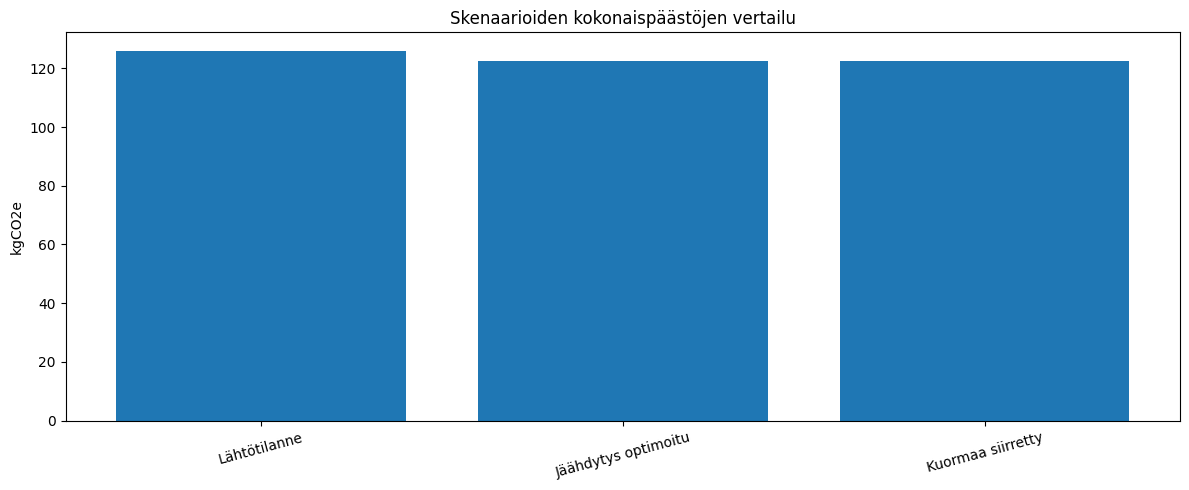

In [29]:
# Kuva 3: Skenaariovertailu
plt.figure()
labels = ['Lähtötilanne']
values = [base['co2e_kg'].sum()]
if cool is not None:
    labels.append('Jäähdytys optimoitu')
    values.append(cool['co2e_kg_optimized'].sum())
if shift is not None:
    labels.append('Kuormaa siirretty')
    values.append(shift['co2e_kg_shifted'].sum())

plt.bar(labels, values)
plt.title('Skenaarioiden kokonaispäästöjen vertailu')
plt.ylabel('kgCO2e')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


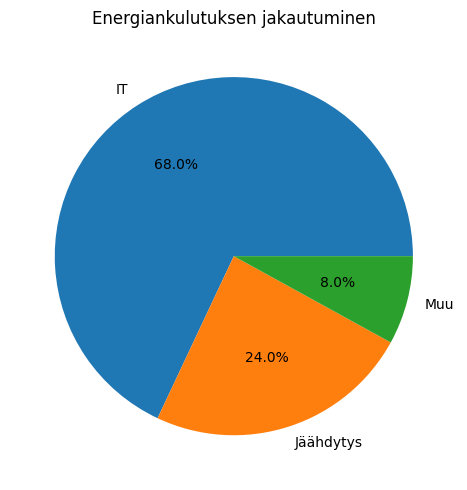

In [30]:
# Kuva 4: IT- ja jäähdytysenergian jakauma (jos saatavilla)
if base['it_kwh'].notna().any() and base['cooling_kwh'].notna().any():
    totals = [base['it_kwh'].sum(), base['cooling_kwh'].sum(), base['other_kwh'].fillna(0).sum()]
    labels = ['IT', 'Jäähdytys', 'Muu']
    plt.figure()
    plt.pie(totals, labels=labels, autopct='%1.1f%%')
    plt.title('Energiankulutuksen jakautuminen')
    plt.tight_layout()
    plt.show()
else:
    print('IT- ja jäähdytyserittelyä ei ole saatavilla.')


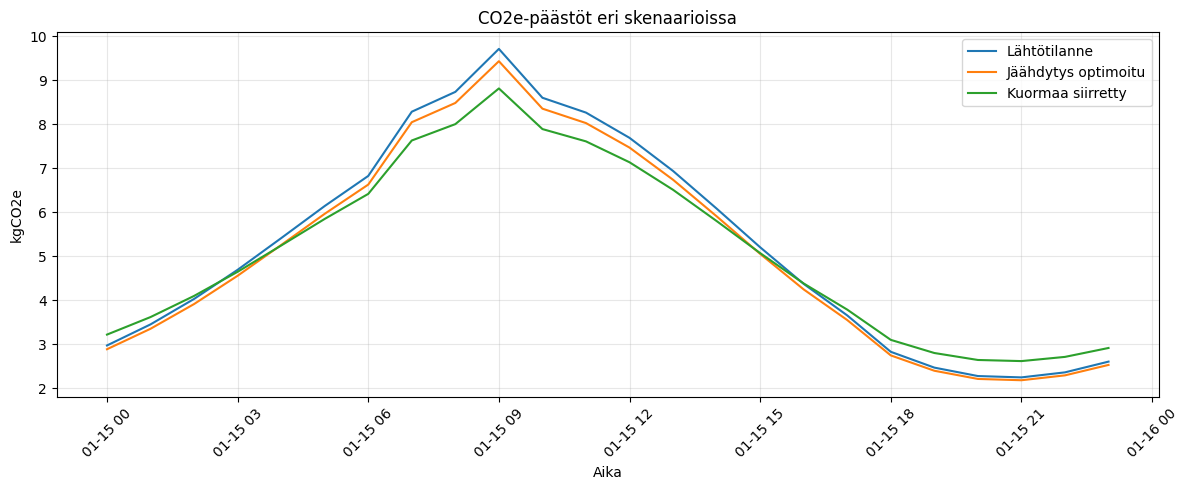

In [31]:
# Kuva 5: Aikasarjavertailu eri skenaarioille
plt.figure()
plt.plot(base['timestamp'], base['co2e_kg'], label='Lähtötilanne')
if cool is not None:
    plt.plot(cool['timestamp'], cool['co2e_kg_optimized'], label='Jäähdytys optimoitu')
if shift is not None:
    plt.plot(shift['timestamp'], shift['co2e_kg_shifted'], label='Kuormaa siirretty')
plt.title('CO2e-päästöt eri skenaarioissa')
plt.xlabel('Aika')
plt.ylabel('kgCO2e')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Tulosyhteenvedon tulkinta
Alla oleva solu laskee muutoksen prosentteina lähtötilanteeseen verrattuna.


In [32]:
result_rows = []
base_co2 = base['co2e_kg'].sum()

for _, row in summary.iterrows():
    delta_pct = 0 if row['Skenaario'] == 'Lähtötilanne' else ((row['CO2e yhteensä (kg)'] - base_co2) / base_co2 * 100)
    result_rows.append({
        'Skenaario': row['Skenaario'],
        'CO2e yhteensä (kg)': row['CO2e yhteensä (kg)'],
        'Muutos lähtötilanteeseen (%)': round(delta_pct, 2)
    })

pd.DataFrame(result_rows)


,Skenaario,CO2e yhteensä (kg),Muutos lähtötilanteeseen (%)
0,Lähtötilanne,125.94,0.00
1,Jäähdytys optimoitu,122.31,-2.88
2,Kuormaa siirretty,122.60,-2.65


## 8. Julkaisuun sopiva sanallinen yhteenveto
Tämä solu tuottaa tekstin, jonka voi hyödyntää raportissa tai artikkeliluonnoksessa.


In [33]:
base_total = round(base['co2e_kg'].sum(), 2)
text = [f'Lähtötilanteessa tarkastelujakson arvioidut kokonaispäästöt olivat {base_total} kgCO2e.']

if cool is not None:
    cool_total = round(cool['co2e_kg_optimized'].sum(), 2)
    cool_change = round((cool_total - base_total) / base_total * 100, 2)
    text.append(f'Jäähdytyksen optimointiskenaariossa kokonaispäästöt olivat {cool_total} kgCO2e, mikä vastaa {cool_change} % muutosta lähtötilanteeseen.')

if shift is not None:
    shift_total = round(shift['co2e_kg_shifted'].sum(), 2)
    shift_change = round((shift_total - base_total) / base_total * 100, 2)
    text.append(f'Kuormansiirtoskenaariossa kokonaispäästöt olivat {shift_total} kgCO2e, mikä vastaa {shift_change} % muutosta lähtötilanteeseen.')

print(' '.join(text))


Lähtötilanteessa tarkastelujakson arvioidut kokonaispäästöt olivat 125.94 kgCO2e. Jäähdytyksen optimointiskenaariossa kokonaispäästöt olivat 122.31 kgCO2e, mikä vastaa -2.88 % muutosta lähtötilanteeseen. Kuormansiirtoskenaariossa kokonaispäästöt olivat 122.6 kgCO2e, mikä vastaa -2.65 % muutosta lähtötilanteeseen.


## 9. CSV-vienti
Voit tallentaa tulokset ulos jatkokäyttöä varten.


In [34]:
summary.to_csv('co2e_skenaarioyhteenveto.csv', index=False)
base.to_csv('co2e_laskenta_lähtötilanne.csv', index=False)
if cool is not None:
    cool.to_csv('co2e_laskenta_jaahdytysoptimoitu.csv', index=False)
if shift is not None:
    shift.to_csv('co2e_laskenta_kuormansiirto.csv', index=False)

print('CSV-tiedostot tallennettu nykyiseen työskentelyhakemistoon.')


CSV-tiedostot tallennettu nykyiseen työskentelyhakemistoon.


## 10. Vinkki GitHub-julkaisuun
Jos haluat jakaa tämän notebookin helposti:
1. lisää `.ipynb` GitHub-repoosi
2. avaa se Colabissa napilla tai linkillä muodossa:

`https://colab.research.google.com/github/<kayttaja>/<repo>/blob/main/datakeskus_co2e_laskuri_colab.ipynb`

Halutessasi voit myöhemmin laajentaa notebookia esimerkiksi:
- PUE-laskentaan
- sähkön hinnan huomioimiseen
- tuntikohtaisiin ennusteisiin
- automaattiseen datan lukemiseen API:sta
